In [1]:
!pip install transformers seqeval sentencepiece tqdm seaborn --no-cache-dir


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=bb982be58b93af0e9b14947f0aa7492e5cc405ce593fe68d9e4a356fa3f242e0
  Stored in directory: /tmp/pip-ephem-wheel-cache-zbynv7qt/wheels/bc/92/f0/243288f899c2eacdfa8c5f9aede4c71a9bad0ee26a01dc5ead
Successfully built seqeval


In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup


In [3]:
config = {
    "data_path": "/kaggle/input/datasetsinggalang/SINGGALANG_oversampled.tsv",
    "model_name": "mesolitica/electra-base-discriminator-bahasa-cased",
    "max_len": 128,
    "batch_size": 16,
    "lr": 3e-5,
    "epochs": 12,
    "dropout": 0.2,
    "patience": 3
}


In [4]:
df = pd.read_csv(config["data_path"], sep="\t", header=None, names=["word","label"])
df.head()


,word,label
0,0,1
1,Ia,O
2,menjabat,O
3,sebagai,O
4,Presiden,O


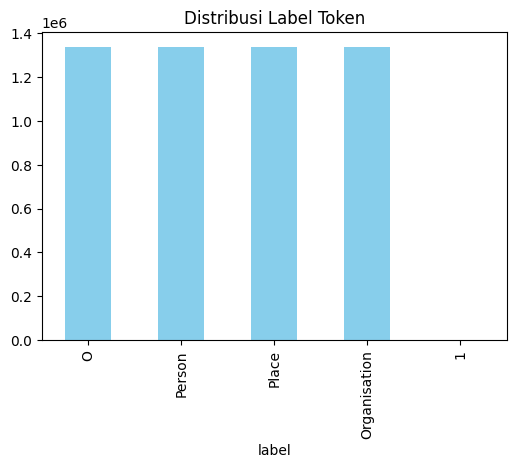

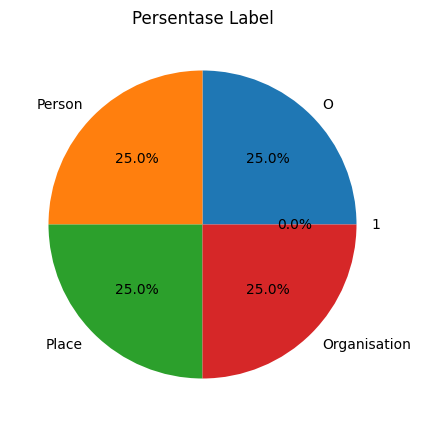

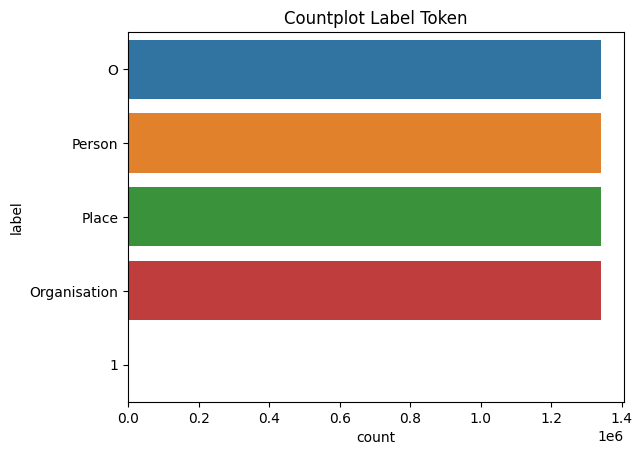

In [5]:
plt.figure(figsize=(6,4))
df["label"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Distribusi Label Token")
plt.show()

plt.figure(figsize=(5,5))
df["label"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Persentase Label")
plt.ylabel("")
plt.show()

sns.countplot(y=df["label"], order=df["label"].value_counts().index)
plt.title("Countplot Label Token")
plt.show()


In [6]:
sentences = []
labels_list = []

temp_w, temp_l = [], []
end_tokens = [".","?","!"]

for w,l in zip(df["word"], df["label"]):
    if isinstance(w, float) or w == "":
        continue

    if w in end_tokens and temp_w:
        temp_w.append(w)
        temp_l.append(l)
        sentences.append(temp_w)
        labels_list.append(temp_l)
        temp_w, temp_l = [], []
    else:
        temp_w.append(w)
        temp_l.append(l)

if temp_w:
    sentences.append(temp_w)
    labels_list.append(temp_l)

print("Total sentences:", len(sentences))


Total sentences: 48981


In [7]:
label_fix = {
    "O":"O","0":"O",".":"O","":"",
    "Person":"Person","1":"Person",
    "Place":"Place","2":"Place",
    "Organisation":"Organisation","3":"Organisation"
}

label_map = {"O":0,"Person":1,"Place":2,"Organisation":3}

clean_labels = []
for seq in labels_list:
    clean_seq = [label_fix.get(l, "O") for l in seq]
    clean_labels.append(clean_seq)

flat_labels = [[label_map[x] for x in seq] for seq in clean_labels]


In [8]:
split = int(0.8 * len(sentences))

train_s = sentences[:split]
train_l = flat_labels[:split]

val_s = sentences[split:]
val_l = flat_labels[split:]

print("Train:", len(train_s), "| Val:", len(val_s))


Train: 39184 | Val: 9797


In [9]:
tokenizer = AutoTokenizer.from_pretrained(config["model_name"])

class NERDataset(Dataset):
    def __init__(self, sents, labels, tokenizer, max_len):
        self.sents = sents
        self.labels = labels
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.sents)

    def __getitem__(self, idx):
        words = self.sents[idx]
        labs  = self.labels[idx]

        enc = self.tok(
            words,
            is_split_into_words=True,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
        )

        word_ids = enc.word_ids()
        label_ids = np.zeros(self.max_len, dtype=int)

        for i, w in enumerate(word_ids):
            if w is not None:
                label_ids[i] = labs[w]

        return {
            "input_ids": torch.tensor(enc["input_ids"]),
            "attention_mask": torch.tensor(enc["attention_mask"]),
            "labels": torch.tensor(label_ids)
        }


tokenizer_config.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [10]:
train_dataset = NERDataset(train_s, train_l, tokenizer, config["max_len"])
val_dataset   = NERDataset(val_s,   val_l, tokenizer, config["max_len"])

train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=config["batch_size"])


In [15]:
class ElectraForNER(nn.Module):
    def __init__(self, cfg, num_labels=4):
        super().__init__()
        self.electra = AutoModel.from_pretrained(cfg["model_name"])
        hidden = self.electra.config.hidden_size

        # Freeze encoder
        for param in self.electra.parameters():
            param.requires_grad = False

        self.dropout = nn.Dropout(cfg["dropout"])
        self.classifier = nn.Linear(hidden, num_labels)

        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, ids, mask, labels=None):
        with torch.no_grad():
            x = self.electra(ids, mask).last_hidden_state

        logits = self.classifier(self.dropout(x))

        if labels is not None:
            active = mask.view(-1) == 1
            logits_active = logits.view(-1, logits.shape[-1])[active]
            labels_active = labels.view(-1)[active]

            raw_loss = self.loss_fn(logits_active, labels_active)

            # NORMALIZED LOSS (differentiable)
            loss_norm = raw_loss / (raw_loss + 1)

            return loss_norm, logits
        else:
            preds = torch.argmax(logits, dim=-1)
            return preds


In [16]:
def model_summary(model):
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("\n===== MODEL SUMMARY =====")
    print("Total Params:", total)
    print("Trainable Params:", train)
    print("Frozen Params:", total-train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ElectraForNER(config).to(device)
model_summary(model)



===== MODEL SUMMARY =====
Total Params: 110029828
Trainable Params: 3076
Frozen Params: 110026752


In [17]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config["lr"]
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_loader),
    num_training_steps=config["epochs"] * len(train_loader)
)


In [ ]:
best_val = float("inf")
bad = 0

for epoch in range(config["epochs"]):

    model.train()
    total_train = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for batch in pbar:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        lbl  = batch["labels"].to(device)

        optimizer.zero_grad()

        loss, logits = model(ids, mask, lbl)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_train += loss.item()
        pbar.set_postfix({"loss_norm": loss.item()})

    # VALIDATION
    model.eval()
    total_val = 0

    with torch.no_grad():
        for batch in val_loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            lbl = batch["labels"].to(device)

            loss, _ = model(ids, mask, lbl)
            total_val += loss.item()

    print(f"Train {total_train:.3f} | Val {total_val:.3f}")

    if total_val < best_val:
        best_val = total_val
        torch.save(model.state_dict(), "best_electra_token_classifier.pt")
        bad = 0
    else:
        bad += 1
        if bad >= config["patience"]:
            print("EARLY STOPPING!")
            break


Epoch 1:   0%|          | 0/2449 [00:00<?, ?it/s]

Train 1060.722 | Val 184.273


Epoch 2:   0%|          | 0/2449 [00:00<?, ?it/s]